# Lizard Island Research Station Acoustic Data Localization

## Purpose of this Notebook
This notebook analyses the data of hydrophone arrays deployed at Lizard Island Research Station, aiming to localize the detected fish sounds and matching it with videos recorded from the underwater cameras, in hopes of recognizing soniferous fish species' sounds.

## Library Setup

In [ ]:
%pip install ecosound
%pip install ipympl

In [2]:
%matplotlib inline
import pandas as pd
import ecosound.core.tools
from ecosound.core.metadata import DeploymentInfo
import ecosound
# how do i import tools, detection, and localization modules from the XAVarrays folder?
# this is where they are: /Users/jasmineyeh/Desktop/WHOI/XAVarrays/localization
import sys
sys.path.append('../localization')
import tools
import detection
import localization

## Define & Load Config Files

### Deployment metadata

In [3]:
# config file
deployment_info_file = r'./config/deployment_info.csv'

# load and display deployment metadata
Deployment = DeploymentInfo()
Deployment.read(deployment_info_file)
Deployment.data

,audio_channel_number,UTC_offset,sampling_frequency,bit_depth,mooring_platform_name,recorder_type,recorder_SN,hydrophone_model,hydrophone_SN,hydrophone_depth,location_name,location_lat,location_lon,location_water_depth,deployment_ID,deployment_date,recovery_date
0,0,10,96000,16,mobile-array,ST4300-HF,5147,HTI-96-Min,1117006,0,LIRS,145.444910,-14.679119,4,LIRS-ROV-20231125-PM,20231125,20231125
1,1,10,96000,16,mobile-array,ST4300-HF,5147,HTI-96-Min,1117005,0,LIRS,-14.679119,145.444910,4,LIRS-ROV-20231125-PM,20231125,20231125
2,2,10,96000,16,mobile-array,ST4300-HF,5147,HTI-96-Min,1117008,0,LIRS,-14.679119,145.444910,4,LIRS-ROV-20231125-PM,20231125,20231125
3,3,10,96000,16,mobile-array,ST4300-HF,5147,HTI-96-Min,1117007,0,LIRS,-14.679119,145.444910,4,LIRS-ROV-20231125-PM,20231125,20231125


### Hydrophone configs

In [4]:
# Define config file
hydrophones_config_file = r'./config/hydrophones_config_LIRS-ROV.csv'

# load and plot hydrophone configuration
hydrophones_config= pd.read_csv(hydrophones_config_file, skipinitialspace=True, dtype={'name': str, 'file_name_root': str}) # load hydrophone coordinates (meters)
hydrophones_config

,name,x,y,z,array_channel,audio_file_channel,data_path,file_name_root
0,Hydrophone 0,0.00,0.8,0.0,0,0,F:\LizardIsland_backup\MobileArray_deployments...,5147.
1,Hydrophone 1,0.00,0.4,0.5,1,1,F:\LizardIsland_backup\MobileArray_deployments...,5147.
2,Hydrophone 2,-0.35,0.0,0.0,2,2,F:\LizardIsland_backup\MobileArray_deployments...,5147.
3,Hydrophone 3,0.35,0.0,0.0,3,3,F:\LizardIsland_backup\MobileArray_deployments...,5147.


## Hydrohpone Coordinate Calculation
### Theoretical Hydrophone Coordinates
Plot out the hydrophone coordinates given the (x, y, z) data from the hydrophone configuration file. 

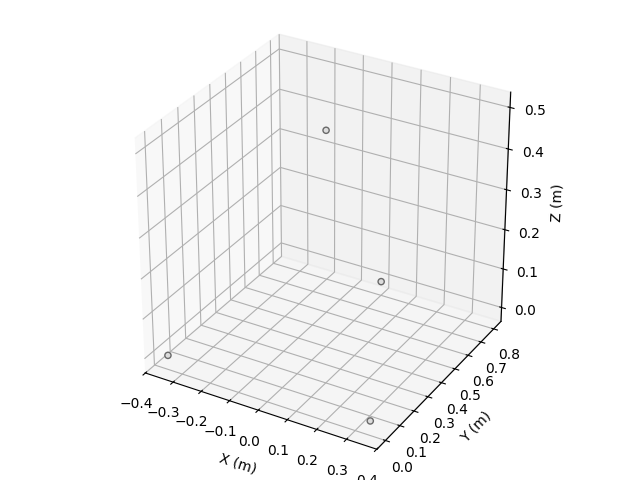

In [5]:
%matplotlib widget
fig, ax = localization.plot_localizations3D(hydrophones=hydrophones_config)

Using matplotlib to plot out the hydrophones' locations, with labeled points and connected lines showing the theoretical model of the deployed hydrophone array.

Distance Matrix:
       A      B      1      2      3      4
A   0.00  40.00  80.00  64.03  35.00  35.00
B  40.00   0.00  40.00  50.00  53.15  53.15
1  80.00  40.00   0.00  64.03  87.32  87.32
2  64.03  50.00  64.03   0.00  72.97  72.97
3  35.00  53.15  87.32  72.97   0.00  70.00
4  35.00  53.15  87.32  72.97  70.00   0.00


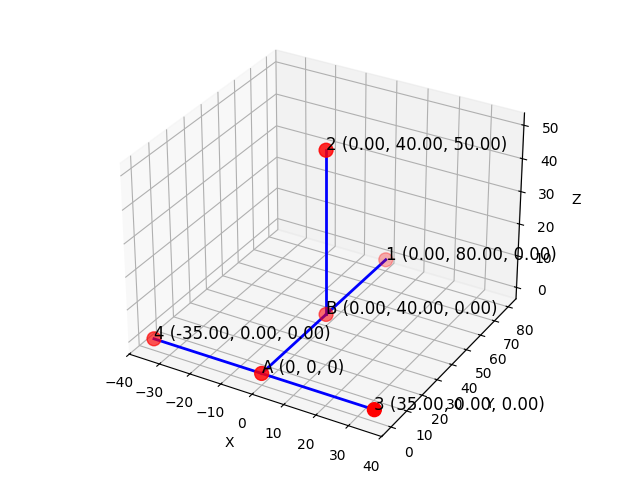

In [8]:
%matplotlib widget
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import numpy as np

# define the six coordinates using integer indexing / slices (not tuples)
defined_coordinates = np.zeros((6, 3))
defined_coordinates[0, :] = [0, 0, 0]
defined_coordinates[1, :] = [0, 40, 0]
defined_coordinates[2, :] = [0, 80, 0]
defined_coordinates[3, :] = [0, 40, 50]
defined_coordinates[4, :] = [35, 0, 0]
defined_coordinates[5, :] = [-35, 0, 0]

# point labels
Points = ['A', 'B', '1', '2', '3', '4']

# calculate the distance matrix
defined_distances = cdist(defined_coordinates, defined_coordinates)
print("Distance Matrix:")
print(pd.DataFrame(defined_distances, index=Points, columns=Points).round(2))

# Create 3D plot
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.scatter(defined_coordinates[:, 0], defined_coordinates[:, 1], defined_coordinates[:, 2], color='red', s=100)

# label the points and add the coordinates as text labels
ax.text(defined_coordinates[0, 0], defined_coordinates[0, 1], defined_coordinates[0, 2], 'A (0, 0, 0)', fontsize=12)
ax.text(defined_coordinates[1, 0], defined_coordinates[1, 1], defined_coordinates[1, 2], f'B ({defined_coordinates[1, 0]:.2f}, {defined_coordinates[1, 1]:.2f}, {defined_coordinates[1, 2]:.2f})', fontsize=12)

# the rest of the points (total - 2)
for i, (x, y, z) in enumerate(defined_coordinates):
    if i > 1:
        ax.text(x, y, z, f'{i-1} ({x:.2f}, {y:.2f}, {z:.2f})', fontsize=12)

# add lines in between the points: AB, A3, A4, B1, B2
ax.plot([defined_coordinates[0, 0], defined_coordinates[1, 0]], [defined_coordinates[0, 1], defined_coordinates[1, 1]], [defined_coordinates[0, 2], defined_coordinates[1, 2]], color='blue', linestyle='-', linewidth=2) # line AB
ax.plot([defined_coordinates[0, 0], defined_coordinates[4, 0]], [defined_coordinates[0, 1], defined_coordinates[4, 1]], [defined_coordinates[0, 2], defined_coordinates[4, 2]], color='blue', linestyle='-', linewidth=2) # line A3
ax.plot([defined_coordinates[0, 0], defined_coordinates[5, 0]], [defined_coordinates[0, 1], defined_coordinates[5, 1]], [defined_coordinates[0, 2], defined_coordinates[5, 2]], color='blue', linestyle='-', linewidth=2) # line A4
ax.plot([defined_coordinates[1, 0], defined_coordinates[2, 0]], [defined_coordinates[1, 1], defined_coordinates[2, 1]], [defined_coordinates[1, 2], defined_coordinates[2, 2]], color='blue', linestyle='-', linewidth=2) # line B1
ax.plot([defined_coordinates[1, 0], defined_coordinates[3, 0]], [defined_coordinates[1, 1], defined_coordinates[3, 1]], [defined_coordinates[1, 2], defined_coordinates[3, 2]], color='blue', linestyle='-', linewidth=2) # line B2  

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.tight_layout()

### Caculating practical hydrophone coordinates
We use Multi-dimensional Scaling (MDS) module from scikit-learn to calculate hydrophone coordinates based on given measurements. We input a symmetrical distance matrix that has the distances between each pair of points, set the number of dimension (`n_componenets`), then the calculation result will be the set of solution such that the between-object distances are preserved as well as possible.

In this case, since we have the actual measurements in between each hydrophone and the nodes, we use MDS to calculate the practical hydrophone coordinates, which is different from the theoretical measurements.

For information about the MDS module, please read the [MDS documentation](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.MDS.html).

/Users/jasmineyeh/opt/anaconda3/envs/actlab/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


Total Optimization Stress: 2.77140351879568
Coordinates:
[[  5.73865756  18.07973246 -20.95407827]
 [ -4.66180635   3.01818782  15.42860133]
 [-15.12051641 -12.75983711  49.10299752]
 [  2.72402876 -42.95682148  -2.19898878]
 [-28.01329242  17.43464049 -30.07124205]
 [ 39.33292886  17.18409782 -11.30728975]]
Coordinates after normalization (A as origin):
[[  0.           0.           0.        ]
 [-10.40046391 -15.06154465  36.3826796 ]
 [-20.85917397 -30.83956957  70.05707578]
 [ -3.0146288  -61.03655395  18.75508949]
 [-33.75194998  -0.64509197  -9.11716378]
 [ 33.5942713   -0.89563464   9.64678852]]
Rotated Coordinates (z-axis):
[[  0.           0.           0.        ]
 [-10.45719908 -15.02220903  36.3826796 ]
 [-20.97534631 -30.76067355  70.05707578]
 [ -3.24482509 -61.0247492   18.75508949]
 [-33.75414305  -0.51778175  -9.11716378]
 [ 33.59065418  -1.02233917   9.64678852]]
Rotated Coordinates (y-axis):
[[  0.           0.           0.        ]
 [ -0.3111451  -15.02220903  37.854

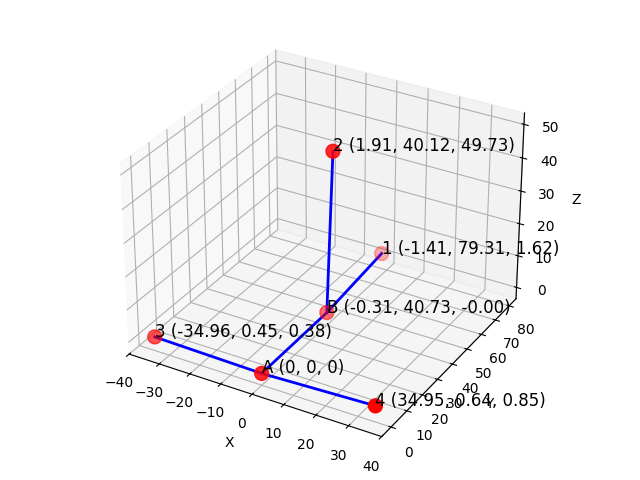

In [10]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS

distances = np.array([
    [0, 40, 80, 64, 35, 35],
    [40, 0, 37.5, 50, 53, 53],
    [80, 37.5, 0, 62, 86, 87],
    [64, 50, 62, 0, 73, 71],
    [35, 53, 86, 73, 0, 70],
    [35, 53, 87, 71, 70, 0]
])

mds = MDS(n_components=3, dissimilarity='precomputed', random_state=42) # 3 for 3D
coordinates = mds.fit_transform(distances)
print(f"Total Optimization Stress: {mds.stress_}")

print("Coordinates:")
print(coordinates)

og_coordinates = coordinates.copy() 

# ---------- Below is for normalization and rotation to make the coordinates more visually intuitive ----------

# Normalize the coordinates
coordinates -= coordinates[0]  # Set A as the origin (0, 0, 0)
coordinates[0] = [0, 0, 0]

print("Coordinates after normalization (A as origin):")
print(coordinates)

A3_vector = coordinates[4] - coordinates[0]  # Vector from A to 3
A4_vector = coordinates[5] - coordinates[0]  # Vector from A to 4

# Rotate around the z-axis
# Calculate the angle between A3_vector and the z-axis
x, y, z = A3_vector
angle_A3 = np.arctan2(x, y)
# Calculate the angle between A4_vector and the z-axis
x, y, z = A4_vector
angle_A4 = np.arctan2(x, y)
# Average the angles to get a single rotation angle
average_angle = -(angle_A3 + angle_A4) / 2
# Create a rotation matrix to rotate the coordinates around the z-axis
rotation_matrix = np.array([
    [np.cos(average_angle), -np.sin(average_angle), 0],
    [np.sin(average_angle), np.cos(average_angle), 0],
    [0, 0, 1]
])
coordinates = coordinates @ rotation_matrix.T

print("Rotated Coordinates (z-axis):")
print(coordinates)

# Rotate the coordinates around the y-axis
angle_A3_y = np.arctan2(np.sqrt(A3_vector[0]**2 + A3_vector[1]**2), A3_vector[2])  # Angle between A3 and x-axis
angle_A4_y = np.arctan2(np.sqrt(A4_vector[0]**2 + A4_vector[1]**2), A4_vector[2])  # Angle between A4 and x-axis
average_angle_y = (angle_A3_y - angle_A4_y) / 2
rotation_matrix_y = np.array([
    [np.cos(average_angle_y), 0, np.sin(average_angle_y)],
    [0, 1, 0],
    [-np.sin(average_angle_y), 0, np.cos(average_angle_y)]
])
coordinates = coordinates @ rotation_matrix_y.T
print("Rotated Coordinates (y-axis):")
print(coordinates)

# rotate around the x-axis to make point B on the xy plane
angle_B_x = - np.pi/2 - np.arctan2(np.sqrt(coordinates[1, 0]**2 + coordinates[1, 1]**2), coordinates[1, 2])  # Angle between B and x-axis
rotation_matrix_x = np.array([
    [1, 0, 0],
    [0, np.cos(angle_B_x), -np.sin(angle_B_x)],
    [0, np.sin(angle_B_x), np.cos(angle_B_x)]
])
coordinates = coordinates @ rotation_matrix_x.T
print("Rotated Coordinates (x-axis):")
print(coordinates)


# Create 3D plot
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.scatter(coordinates[:, 0], coordinates[:, 1], coordinates[:, 2], color='red', s=100)

# label the points and add the coordinates as text labels
ax.text(coordinates[0, 0], coordinates[0, 1], coordinates[0, 2], 'A (0, 0, 0)', fontsize=12)
ax.text(coordinates[1, 0], coordinates[1, 1], coordinates[1, 2], f'B ({coordinates[1, 0]:.2f}, {coordinates[1, 1]:.2f}, {coordinates[1, 2]:.2f})', fontsize=12)

# the rest of the points
for i, (x, y, z) in enumerate(coordinates):
    if i > 1:
        ax.text(x, y, z, f'{i-1} ({x:.2f}, {y:.2f}, {z:.2f})', fontsize=12)

# add lines in between the points: AB, A3, A4, B1, B2
ax.plot([coordinates[0, 0], coordinates[1, 0]], [coordinates[0, 1], coordinates[1, 1]], [coordinates[0, 2], coordinates[1, 2]], color='blue', linestyle='-', linewidth=2) # line AB
ax.plot([coordinates[0, 0], coordinates[4, 0]], [coordinates[0, 1], coordinates[4, 1]], [coordinates[0, 2], coordinates[4, 2]], color='blue', linestyle='-', linewidth=2) # line A3
ax.plot([coordinates[0, 0], coordinates[5, 0]], [coordinates[0, 1], coordinates[5, 1]], [coordinates[0, 2], coordinates[5, 2]], color='blue', linestyle='-', linewidth=2) # line A4
ax.plot([coordinates[1, 0], coordinates[2, 0]], [coordinates[1, 1], coordinates[2, 1]], [coordinates[1, 2], coordinates[2, 2]], color='blue', linestyle='-', linewidth=2) # line B1
ax.plot([coordinates[1, 0], coordinates[3, 0]], [coordinates[1, 1], coordinates[3, 1]], [coordinates[1, 2], coordinates[3, 2]], color='blue', linestyle='-', linewidth=2) # line B2  

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.tight_layout()

In [11]:
from scipy.spatial.distance import cdist

# actual point labels
Points = ['A', 'B', '1', '2', '3', '4']

# print out the coordinates of the points
print("Final Coordinates of the points:")
for i, (x, y, z) in enumerate(coordinates):
    print(f"Point {Points[i]}: ({x:.2f}, {y:.2f}, {z:.2f})")

# Calculate the distances between the points that MDS generated
generated_distances = cdist(coordinates, coordinates)

# print it in a matrix form
print("\nGenerated Distance Matrix:")
print(pd.DataFrame(generated_distances, index=Points, columns=Points).round(2))

# Compare the generated distances with the original distances
print("\nOriginal Distance Matrix:")
print(pd.DataFrame(distances, index=Points, columns=Points).round(2))

# Calculate the difference between the generated and original distances
difference = generated_distances - distances
print("\nDifference Matrix (Generated - Original):")
print(pd.DataFrame(difference, index=Points, columns=Points).round(2))

# Calculate the difference between the defined and original distances
defined_difference = defined_distances - distances
print("\nDifference Matrix (Defined - Original):")
print(pd.DataFrame(defined_difference, index=Points, columns=Points).round(2))


Final Coordinates of the points:
Point A: (0.00, 0.00, 0.00)
Point B: (-0.31, 40.73, -0.00)
Point 1: (-1.41, 79.31, 1.62)
Point 2: (1.91, 40.12, 49.73)
Point 3: (-34.96, 0.45, 0.38)
Point 4: (34.95, 0.64, 0.85)

Generated Distance Matrix:
       A      B      1      2      3      4
A   0.00  40.73  79.34  63.92  34.97  34.96
B  40.73   0.00  38.63  49.79  53.14  53.39
1  79.34  38.63   0.00  62.15  85.71  86.67
2  63.92  49.79  62.15   0.00  73.27  70.99
3  34.97  53.14  85.71  73.27   0.00  69.91
4  34.96  53.39  86.67  70.99  69.91   0.00

Original Distance Matrix:
      A     B     1     2     3     4
A   0.0  40.0  80.0  64.0  35.0  35.0
B  40.0   0.0  37.5  50.0  53.0  53.0
1  80.0  37.5   0.0  62.0  86.0  87.0
2  64.0  50.0  62.0   0.0  73.0  71.0
3  35.0  53.0  86.0  73.0   0.0  70.0
4  35.0  53.0  87.0  71.0  70.0   0.0

Difference Matrix (Generated - Original):
      A     B     1     2     3     4
A  0.00  0.73 -0.66 -0.08 -0.03 -0.04
B  0.73  0.00  1.13 -0.21  0.14  0.39
1 -

## Localization
### Localization Parameters

In [114]:
localization_config_file = r'./config/localization_config_LIRS-ROV.yaml'
localization_config = ecosound.core.tools.read_yaml(localization_config_file)
localization_config

{'ENVIRONMENT': {'sound_speed_mps': 1484},
 'TDOA': {'ref_channel': 1,
  'upsample_res_sec': 1e-05,
  'normalize': False,
  'min_corr_val': 0.5,
  'number_freq_bands': 4,
  'min_bandwidth_hz': 200,
  'energy_window_perc': 80},
 'GRIDSEARCH': {'x_limits_m': [-3, 3],
  'y_limits_m': [-3, 3],
  'z_limits_m': [-0.5, 4],
  'spacing_m': 0.02}}

In [ ]:
# localization 
# need to figure out how to transform the detection files from the export format from raven to the desired format for the localization module